In [1]:
""" Compare against pore water chemistry data of Natalie/Verity
Measurements depths are relative to hollow surface"""
import pandas as pd
import numpy as np
import os
from datetime import datetime
from utils.analysis import vert_interp
from utils.constants import chamber_levels_complete, chamber_list_complete_dict
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from glob import glob
import xarray as xr
#from scipy.stats import pearsonr, spearmanr, chi2, probplot
#from statsmodels.tools import add_constant
#from statsmodels.regression.mixed_linear_model import MixedLM
from scipy.stats import linregress
from matplotlib import rcParams

rcParams['font.size'] = 16
rcParams['axes.titlesize'] = 16

chambers_ordered = {
    'amb': ['07', '06', '20', '13', '08', '17'], 
    'elev': ['19', '11', '04', '16', '10']
}
xticklabels = ['TAMB', 'T0.00', 'T2.25','T4.50', 'T6.75', 'T9.00', 
               'T0.00CO2', 'T2.25CO2', 'T4.5CO2', 'T6.75CO2', 'T9.00CO2']

# which depth of observation to look at, pick from depth_list
depth_list = ['0.0', '0.3', '0.5', '1.0', '2.0', '3.0']
DEPTH = 0.3

In [2]:
# Observed dissolved N & P at multiple depths
data = pd.read_csv(
    os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'input', 
                 'SPRUCE_plot_porewater_chemistry_release_20240617.csv'),
    na_values=[-9999, -8888]
)
data['DATE'] = data['DATE'].apply(lambda x: datetime.strptime(str(x), '%Y%m%d'))
data = data.loc[(pd.DatetimeIndex(data['DATE']).year >= 2015) & 
                (~data['PLOT'].isin([2,5,9,14,15,21])), 
                ['PLOT', 'DEPTH', 'DATE', 'NH4', 'NO3', 'SRP', 'TN', 'TP']]
data['PLOT'] = [f'{x:02d}' for x in data['PLOT']]
data['dT'] = [chamber_levels_complete[x][0] for x in data['PLOT']]
data['CO2'] = [chamber_levels_complete[x][1] for x in data['PLOT']]

data['NH4+NO3'] = data['NH4'] + data['NO3']

data = data.loc[np.isclose(data['DEPTH'], DEPTH), :]
data = data.sort_values(by = 'DATE')

if DEPTH == 0.3:
    # apparently there is some outlier
    data.loc[data['PLOT'].isin(['10', '19']) & (data['NH4'] > 1.5)] = np.nan

In [3]:
# Collect modeled dissolved nutrients, layersize
ensemble_id = None
year_range = range(2015, 2022)
plot_list = list(chamber_levels_complete.keys())
prefix_list = ['20231116', '20240323']

tvec = pd.date_range('2015-01-01', '2021-12-31')
tvec = tvec[(tvec.month != 2) | (tvec.day != 29)]
sims_data = {}

for prefix in prefix_list:
    sims_data[(prefix, 'SMIN_NO3_vr')] = \
        pd.DataFrame(np.nan, 
                    columns = pd.MultiIndex.from_product([['hummock', 'hollow', 'average'],
                                                            plot_list]),
                    index = tvec)
    sims_data[(prefix, 'SMIN_NH4_vr')] = sims_data[(prefix, 'SMIN_NO3_vr')].copy()
    sims_data[(prefix, 'SMINN_vr')] = sims_data[(prefix, 'SMIN_NO3_vr')].copy()
    sims_data[(prefix, 'SOLUTIONP_vr')] = sims_data[(prefix, 'SMIN_NO3_vr')].copy()

    for plot in plot_list:
        if not "UQ" in prefix:
            rundir = os.path.join(os.environ['E3SM_ROOT'], 'output', 
                                f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', f'spruce_treatments', 
                                f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run')
        else:
            rundir = os.path.join(os.environ['E3SM_ROOT'], 'output', 'UQ',
                                f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', ensemble_id, 
                                f'P{chamber_list_complete_dict[plot]}')

        flist = sorted(glob(rundir + "/*.h1.*.nc"))
        flist = [f for f in flist if \
                int(f.split('/')[-1].split('.')[-2].split('-')[0]) in year_range]
        hr = xr.open_mfdataset(flist)

        for var in ['SMINN_vr', 'SMIN_NH4_vr', 'SMIN_NO3_vr', 'SOLUTIONP_vr']:
            LEVGRND = np.array([0.007100635, 0.027925, 0.06225858, 0.1188651, 0.2121934,
                                0.3660658, 0.6197585, 1.038027, 1.727635, 2.864607, 4.739157,
                                7.829766, 12.92532, 21.32647, 35.17762])
            LEVGRND_I = np.append(np.insert(
                (LEVGRND[1:] + LEVGRND[:-1])*0.5, 0, 0
            ), LEVGRND[-1] + 0.5 * (LEVGRND[-1] - LEVGRND[-2]))
            THICKNESS = np.diff(LEVGRND_I)

            target_nodes = [DEPTH]
            input_nodes = LEVGRND
            target_single_level = True

            for col, colname in enumerate(['hummock', 'hollow']):
                input_data = hr[var][:, :, col].values / hr['H2OSOI'][:, :, col].values

                result = vert_interp(target_nodes, input_nodes, input_data, 
                                    target_single_level)
                sims_data[(prefix, var)].loc[:, (colname, plot)] = result[:, 0]
        hr.close()

    for var in ['SMINN_vr', 'SMIN_NH4_vr', 'SMIN_NO3_vr', 'SOLUTIONP_vr']:
        sims_data[(prefix, var)].loc[:, 'average'] = \
            sims_data[(prefix, var)].loc[:, 'hummock'].values * 0.64 + \
            sims_data[(prefix, var)].loc[:, 'hollow'].values * 0.36

In [4]:
# Compare the temporal trend in each chamber between the observation and simulated values
collect_trend = pd.DataFrame(np.nan, 
                             index = chambers_ordered['amb'] + chambers_ordered['elev'], 
                             columns = pd.MultiIndex.from_product([
                                 ['NH4','NO3','SRP'], 
                                 ['Obs','ELM-default','ELM-nutrient']
                             ]))
collect_trend_p = collect_trend.copy()

for sim_name, obs_name in zip(['SMIN_NH4_vr','SMIN_NO3_vr','SOLUTIONP_vr'],
                              ['NH4','NO3','SRP']):

    # observed data
    obs_data_var = data[['PLOT', 'DATE', obs_name]
                        ].set_index(['DATE', 'PLOT']).iloc[:,0].dropna().unstack()

    day_since_begin = (obs_data_var.index - obs_data_var.index[0]).days
    for col in chambers_ordered['amb'] + chambers_ordered['elev']:

        filt = ~np.isnan(obs_data_var[col].values)
 
        res = linregress(day_since_begin[filt], obs_data_var[col].values[filt])
        collect_trend.loc[col, (obs_name, 'Obs')] = res.slope
        collect_trend_p.loc[col, (obs_name, 'Obs')] = res.pvalue

    for p, (prefix, name) in enumerate(zip(prefix_list, ['default','nutrient'])):

        # growing season simulated data
        sims_data_var = sims_data[(prefix, sim_name)]
        sims_data_var = sims_data_var.loc[:, 'hollow']

        sims_data_matched = pd.DataFrame(np.nan, index = obs_data_var.index, 
                                         columns = obs_data_var.columns)
        for plot in chambers_ordered['amb'] + chambers_ordered['elev']:
            sims_data_matched.loc[:, plot] = \
                sims_data_var.loc[obs_data_var.index, plot]

        for col in chambers_ordered['amb'] + chambers_ordered['elev']:
            filt = ~np.isnan(obs_data_var[col].values)

            res = linregress(day_since_begin[filt], sims_data_matched[col].values[filt])
            collect_trend.loc[col, (obs_name, f'ELM-{name}')] = res.slope
            collect_trend_p.loc[col, (obs_name, f'ELM-{name}')] = res.pvalue
collect_trend.index = xticklabels
collect_trend_p.index = xticklabels

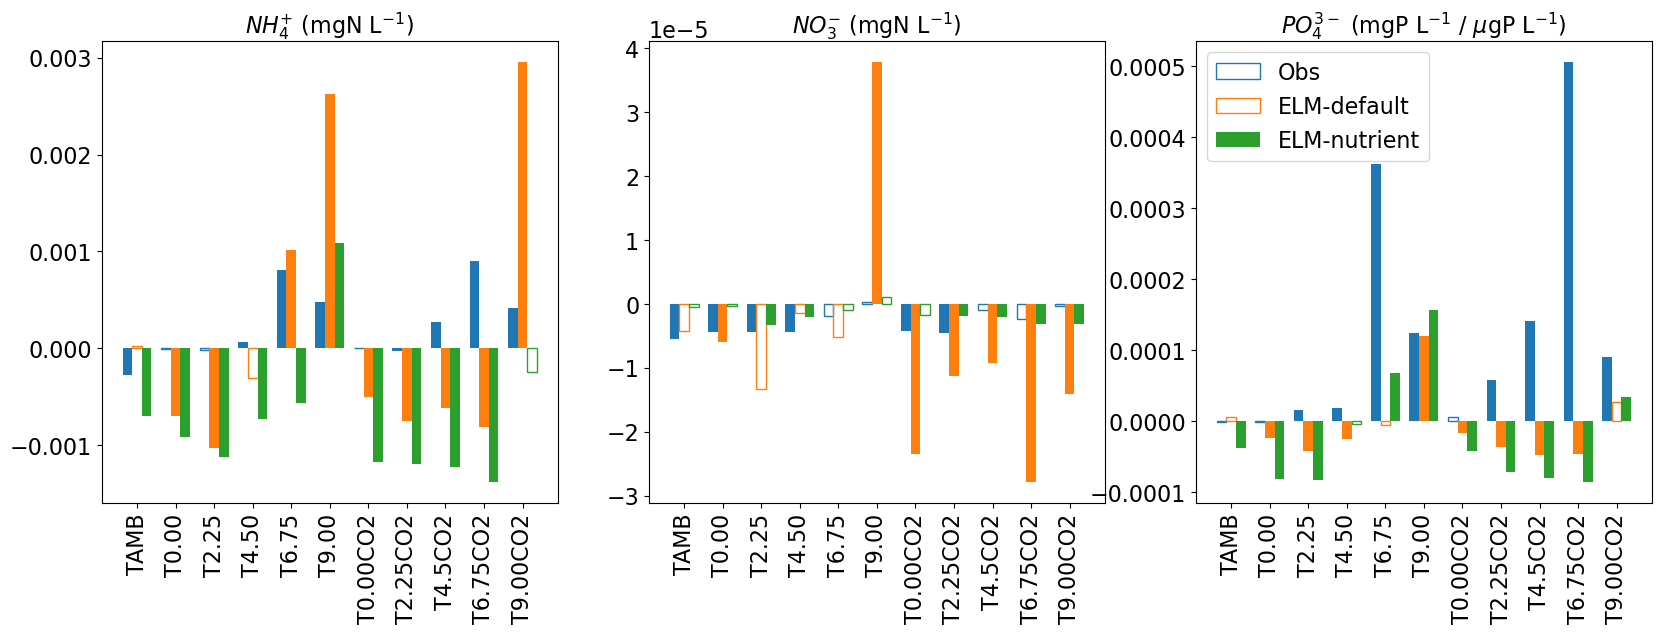

In [5]:
def plot_trends_with_significance(ax, trend_df, pval_df, significance_level=0.05, 
                                  colors=['#1f77b4', '#ff7f0e', '#2ca02c']):
    """
    Plot trends as bars with hollow style for non-significant trends.
    
    Parameters:
    -----------
    ax : matplotlib.axes.Axes
        The axes object to plot on
    trend_df : pandas.DataFrame
        DataFrame containing trend values
    pval_df : pandas.DataFrame
        DataFrame containing corresponding p-values
    significance_level : float, optional
        P-value threshold for significance (default: 0.05)
    colors : list, optional
        List of colors for each column
    """
    
    bar_width = 0.25
    x = np.arange(len(trend_df.index))
    
    for i, (col, color) in enumerate(zip(trend_df.columns, colors)):
        trends = trend_df[col]
        pvals = pval_df[col]

        bars = ax.bar(x + i*bar_width, trends, bar_width, 
                     label=col, color=color)

        # Make non-significant bars hollow
        for bar, pval in zip(bars, pvals):
            if pval > significance_level:
                bar.set_facecolor('none')
                bar.set_edgecolor(color)

    # Customize the plot
    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(trend_df.index, rotation=90)

    return ax

fig, axes = plt.subplots(1, 3, figsize = (20, 6), sharex = True, sharey = False)
for i, obs_name in enumerate(['NH4','NO3']):
    plot_trends_with_significance(
        axes.flat[i], collect_trend.loc[:,obs_name], collect_trend_p.loc[:,obs_name]
    )
    if i == 0:
        axes.flat[i].set_title('$NH_4^{+}$ (mgN L$^{-1}$)')
    elif i == 1:
        axes.flat[i].set_title('$NO_3^{-}$ (mgN L$^{-1}$)')

# scale the modeled values by 1e3 for SRP because it is too small
obs_name = 'SRP'
temp = collect_trend.loc[:,obs_name].copy()
temp.loc[:, ['ELM-default', 'ELM-nutrient']] = temp.loc[:, ['ELM-default', 
                                                            'ELM-nutrient']].values * 1e3
plot_trends_with_significance(
    axes.flat[2], temp, collect_trend_p.loc[:,obs_name]
)
axes.flat[2].set_title('$PO_4^{3-}$ (mgP L$^{-1}$ / $\mu$gP L$^{-1}$)')
axes.flat[2].legend()

/tmp/ipykernel_1095007/2300262884.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('magma_r')
/tmp/ipykernel_1095007/2300262884.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('magma_r')
/tmp/ipykernel_1095007/2300262884.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('magma_r')
/tmp/ipykernel_1095007/2300262884.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be r

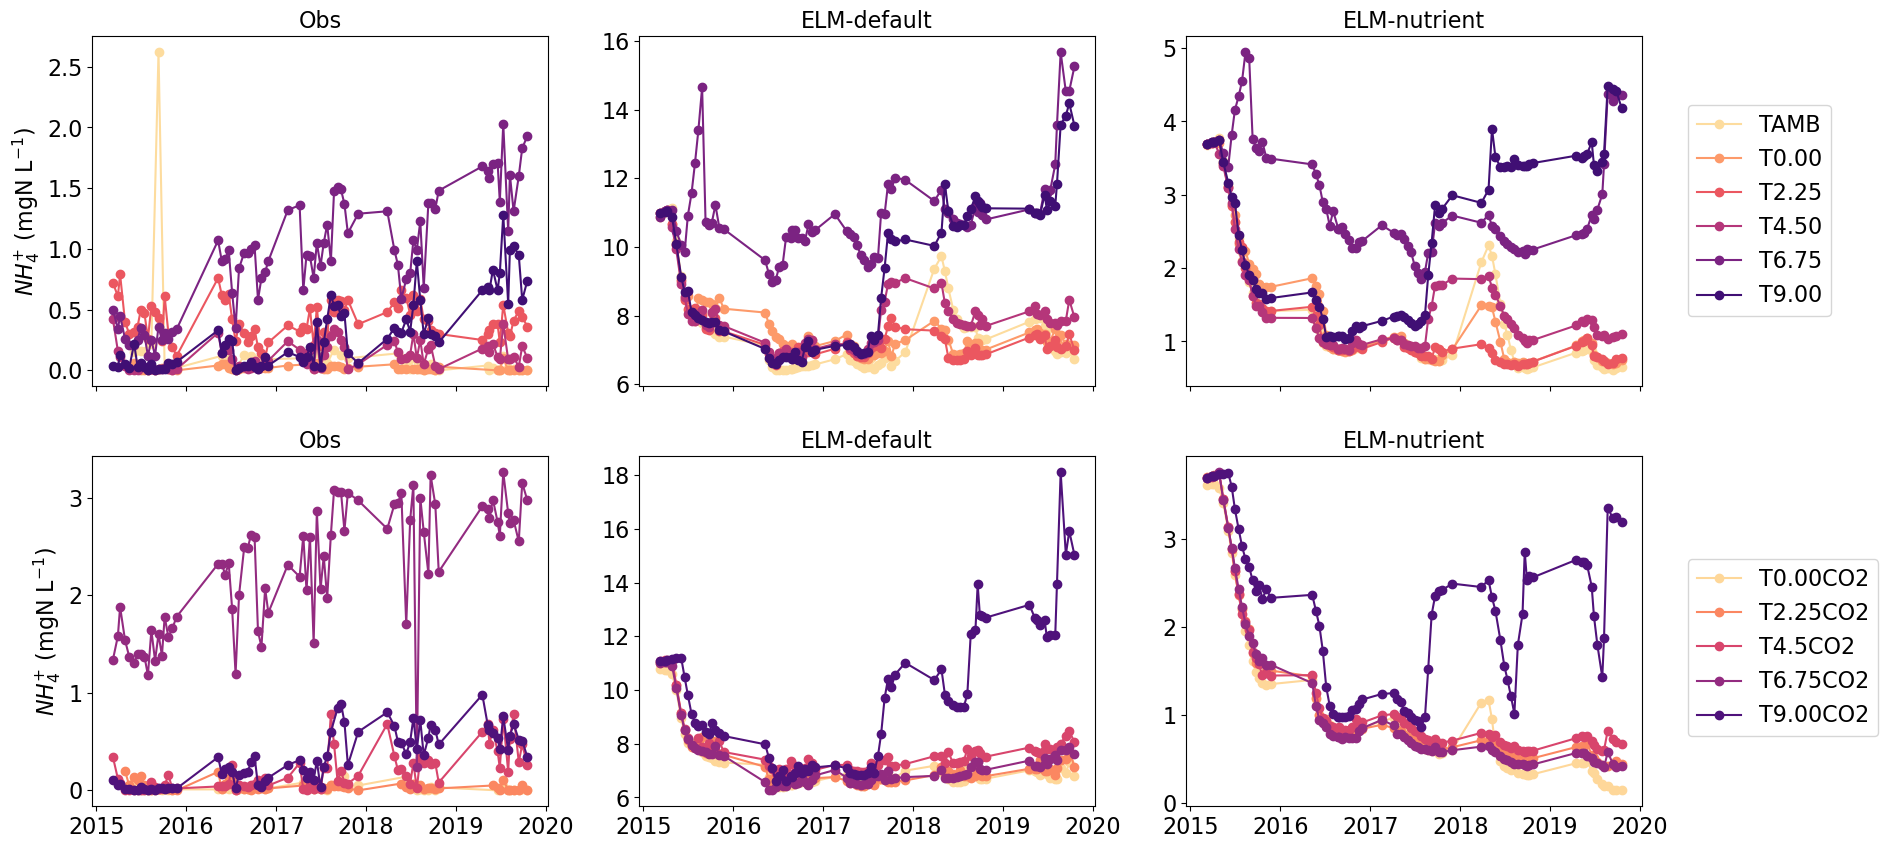

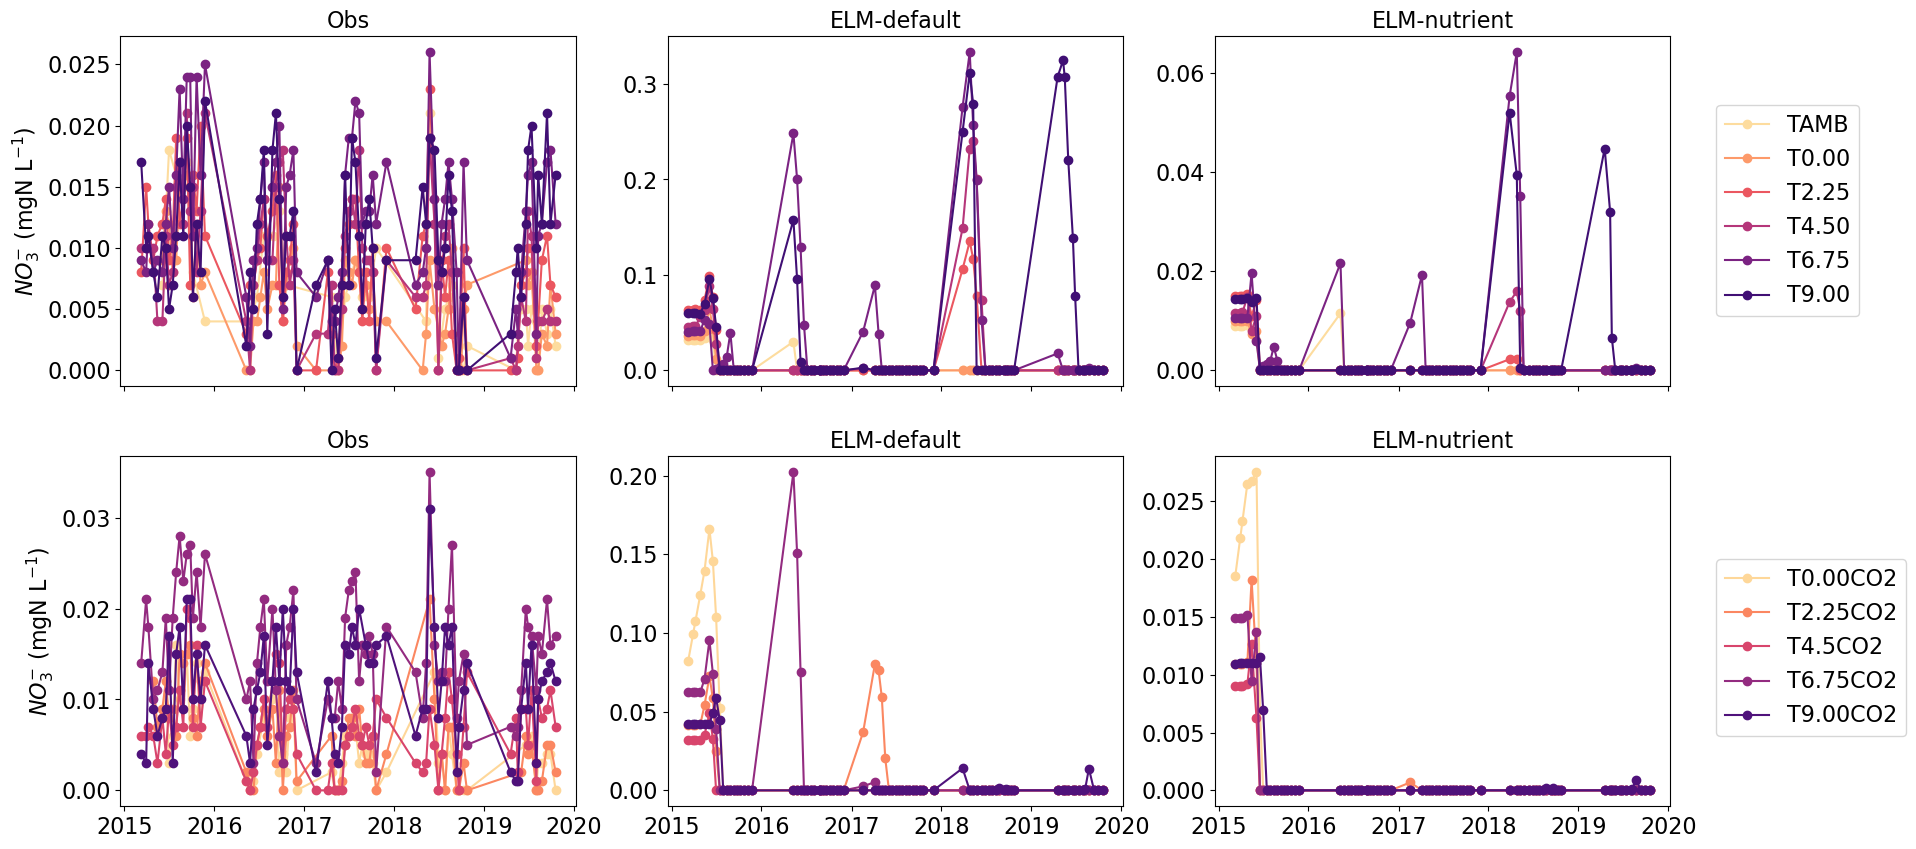

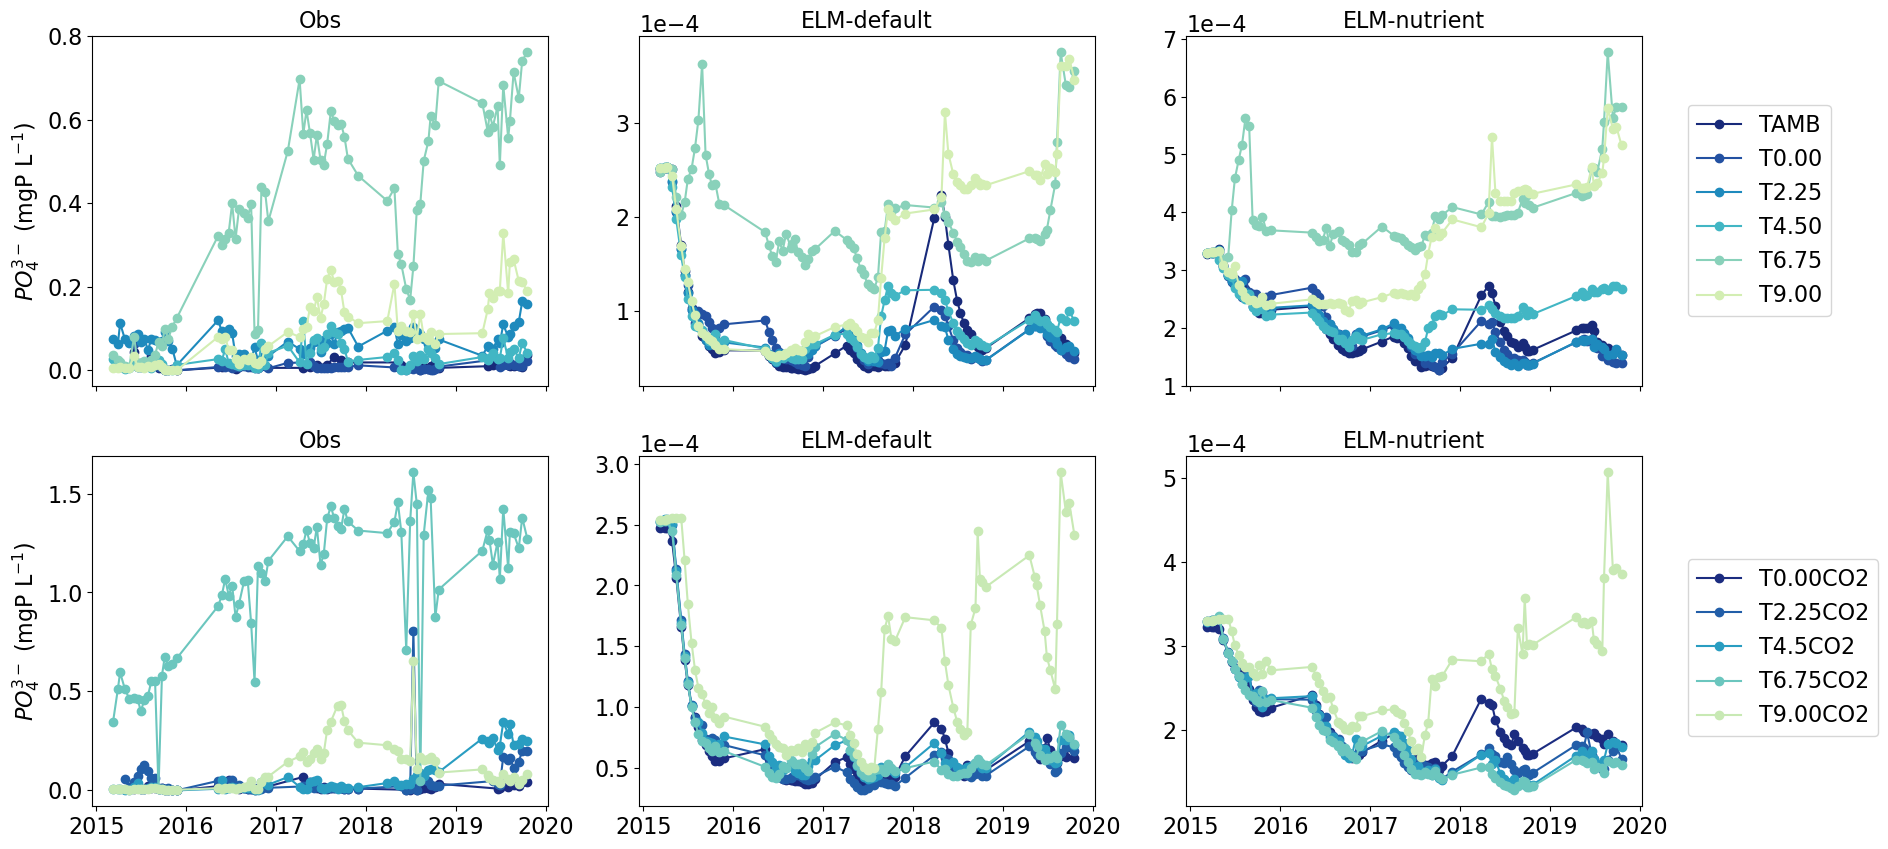

In [6]:
for sim_name, obs_name in zip(['SMIN_NH4_vr','SMIN_NO3_vr','SOLUTIONP_vr'],
                              ['NH4','NO3','SRP']):
    fig, axes = plt.subplots(2, 3, figsize = (20, 10), sharex = True, sharey = False)

    for j, co2 in enumerate(['amb', 'elev']):
        if co2 == 'amb':
            label_list = xticklabels[:6]
        else:
            label_list = xticklabels[6:]

        if obs_name == 'SRP':
            cmap = get_cmap('YlGnBu_r')
        else:
            cmap = get_cmap('magma_r')
        clist = [ cmap((i+0.5) / (len(label_list)+1)) for i in range(len(label_list)) ]

        # observation
        ax = axes[j, 0]
        count = 0
        for plot, label in zip(chambers_ordered[co2], label_list):
            ax.plot(data.loc[data['PLOT'] == plot, 'DATE'], 
                    data.loc[data['PLOT'] == plot,  obs_name], 
                    '-o', label = label, color = clist[count])
            count += 1
        ax.set_title('Obs')
        if obs_name == 'NH4':
            ylabel = '$NH_4^{+}$ (mgN L$^{-1}$)'
        elif obs_name == 'NO3':
            ylabel = '$NO_3^{-}$ (mgN L$^{-1}$)'
        else:
            ylabel = '$PO_4^{3-}$ (mgP L$^{-1}$)'
        ax.set_ylabel(ylabel)

        obs_data_var = data[['PLOT', 'DATE', obs_name]
                            ].set_index(['DATE', 'PLOT']).iloc[:,0].dropna().unstack()

        # simulations
        for p, (prefix,pname) in enumerate(zip(prefix_list, ['ELM-default','ELM-nutrient']), 1):

            # growing season simulated data
            sims_data_var = sims_data[(prefix, sim_name)]
            sims_data_var = sims_data_var.loc[:, 'hollow']

            sims_data_matched = pd.DataFrame(np.nan, index = obs_data_var.index, 
                                            columns = obs_data_var.columns)
            for plot in chambers_ordered['amb'] + chambers_ordered['elev']:
                sims_data_matched.loc[:, plot] = \
                    sims_data_var.loc[obs_data_var.index, plot]

            ax = axes[j, p]
            count = 0
            for plot, label in zip(chambers_ordered[co2], label_list):
                ax.plot(sims_data_matched.index, 
                        sims_data_matched.loc[:, plot], 
                        '-o', label = label, color = clist[count])
                count += 1
                ax.set_title(pname)
                #ax.set_ylabel(f'{sim_name}/H2OSOI (mg L-1)')

            if p == 2:
                ax.legend(loc = (1.1, 0.2))

            if obs_name == 'SRP':
                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))